# Valid Frames

This notebook checks the valid frames for responses and videos across recordings

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from ssdatam.dataset import DataSet

Define the paths used to access data and metadata.

In [5]:
repo_root = Path.cwd().parent

# data folder
folder_data = repo_root / 'data'

# metadata folder
folder_meta = repo_root / 'metadata'

# mice/recording folders
all_recording_folders = [
    'dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29515-10-12-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29623-4-9-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20',
]

Initialize a `DataSet` object to handle the full dataset.

In [6]:
# Inizialize and object from DataSet to handle the dataset
ds = DataSet(folder_data, 
             folder_metadata=folder_meta,
             recording=all_recording_folders, 
             check=True,
             verbose=True)

# Load the metadat for all triasls
trials_df = ds.get_trials_metadata()

# Mapping from recording name to rec-animalID-session-scan format
mapping = {}
for rec in ds.recording:
    x = rec.split("-")
    mapping[rec] = f"rec-{ds.info[rec]['animal_id']}-{ds.info[rec]['session']}-{ds.info[rec]['scan_idx']}"



Initializing DataSet -------------------------------------------------------------------------------

Checking the data ----------------------------------------------------------------------------------
 > All data files seem consistent across trials and data types for recording dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce.
 > All data files seem consistent across trials and data types for recording dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce.
 > All data files seem consistent across trials and data types for recording dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce.
 > All data files seem consistent across trials and data types for recording dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce.
 > All data files seem consistent across trials and data types for recording dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce.
 > All data files seem consistent across trials and data types for recording dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9

# Valid Responses

In [7]:
# valid responses per recording
trials_df = ds.trials_df.copy()
trials_df["recording_short_label"] = trials_df["recording"].map(mapping)
print("Number of valid responses per recording:")
trials_df[trials_df["valid_response"]].groupby("recording_short_label").size()

Number of valid responses per recording:


recording_short_label
rec-29156-11-10    720
rec-29228-2-10     704
rec-29234-6-9      729
rec-29513-3-5      714
rec-29514-2-9      723
rec-29515-10-12    406
rec-29623-4-9      385
rec-29647-19-8     414
rec-29712-5-9      419
rec-29755-2-8      413
dtype: int64

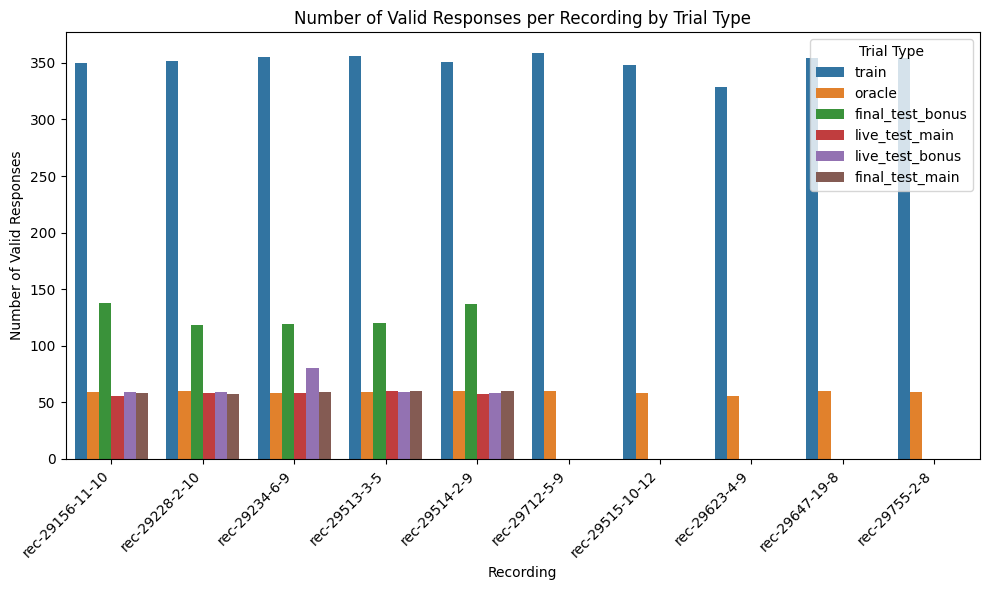

<Figure size 640x480 with 0 Axes>

In [8]:
# plot a bar plot of the number of valid responses per recording separated by trial_type (as hue)
plt.figure(figsize=(10, 6))
sns.countplot(data=trials_df[trials_df["valid_response"]], x="recording_short_label", hue="trial_type")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Recording")
plt.ylabel("Number of Valid Responses")
plt.title("Number of Valid Responses per Recording by Trial Type")
plt.legend(title="Trial Type")
plt.tight_layout()
plt.show()
# save
plt.savefig(repo_root / "figures" / "valid_responses_per_recording.png", dpi=300)

## Valid frames per label

Distribution of valid frames for NaturalVideo trials:
- Minimum valid frames: 300
- Maximum valid frames: 300
- Mean valid frames: 300.0


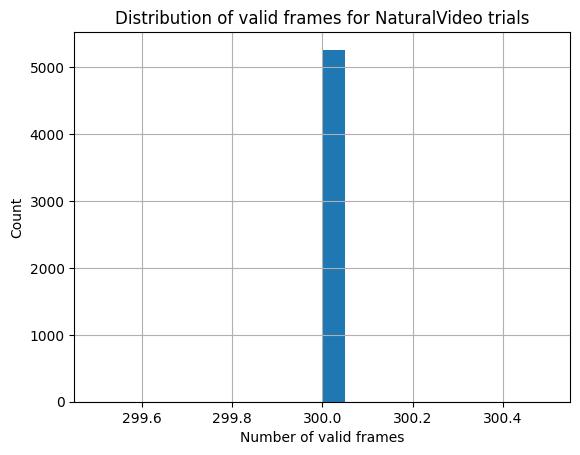

Distribution of valid frames for NaturalImages trials:
- Minimum valid frames: 305
- Maximum valid frames: 326
- Mean valid frames: 316.40677966101697


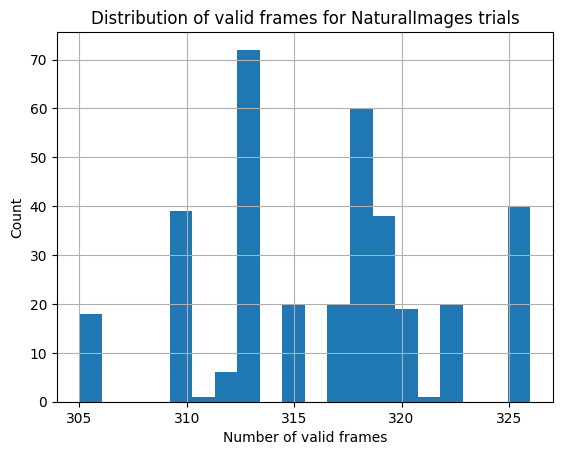

Distribution of valid frames for PinkNoise trials:
- Minimum valid frames: 324
- Maximum valid frames: 324
- Mean valid frames: 324.0


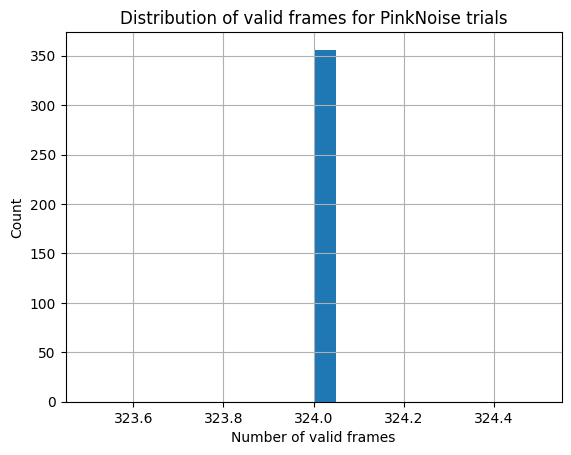

Distribution of valid frames for RandomDots trials:
- Minimum valid frames: 240
- Maximum valid frames: 240
- Mean valid frames: 240.0


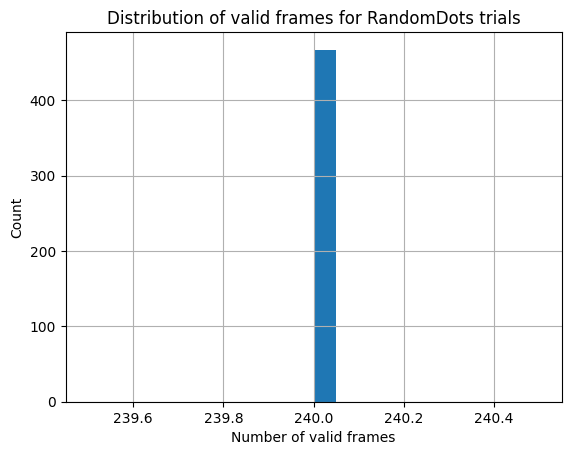

Distribution of valid frames for GaussianDot trials:
- Minimum valid frames: 315
- Maximum valid frames: 315
- Mean valid frames: 315.0


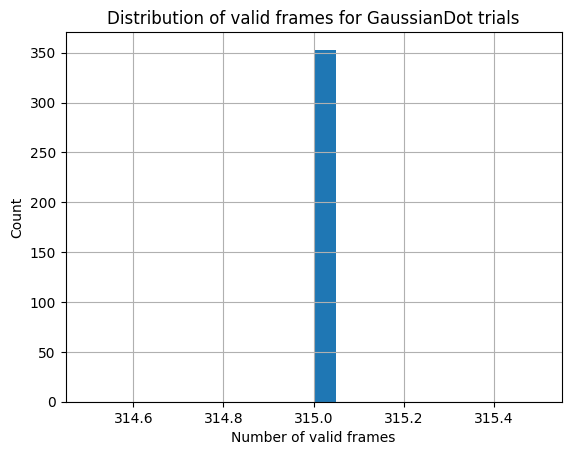

Distribution of valid frames for Gabor trials:
- Minimum valid frames: 300
- Maximum valid frames: 300
- Mean valid frames: 300.0


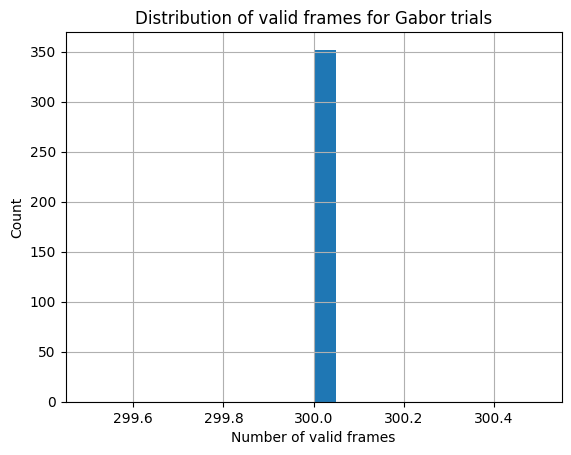

In [12]:
trials_df = ds.trials_df.copy()
labels_order=["NaturalVideo", "NaturalImages", "PinkNoise","RandomDots","GaussianDot","Gabor"]

for lab in labels_order:
    df_ = trials_df[(trials_df["label"] == lab) & (trials_df["valid_trial"])]["valid_frames"]
    print(f"Distribution of valid frames for {lab} trials:")
    print(f"- Minimum valid frames: {df_.min()}")
    print(f"- Maximum valid frames: {df_.max()}")
    print(f"- Mean valid frames: {df_.mean()}")
    df_.hist(bins=20)
    plt.title(f"Distribution of valid frames for {lab} trials")
    plt.xlabel("Number of valid frames")
    plt.ylabel("Count")
    plt.show()

## Differences in valid frames

See how many trials there are per recording with a different number of valid frames between the video and the response

In [14]:
df_ = trials_df[(trials_df["valid_trial"]) & (trials_df["valid_response"])].copy()

# Columns to compare; keep only those that exist in the dataframe
# candidate_cols = [
#     "valid_frames_response",
#     "valid_frames_video",
#     "valid_frames_pupil",
#     "valid_frame_pupil",  
#     "valid_frames_gaze",
#     "valid_frames_locomotion",
# ]

candidate_cols = [
    "valid_frames_response",
    "valid_frames_video",
]
compare_cols = [c for c in candidate_cols if c in df_.columns]

if len(compare_cols) < 2:
    raise ValueError(f"Need at least 2 columns to compare, found: {compare_cols}")

# Keep rows where at least one pair of compared columns differs
mask_diff = df_[compare_cols].nunique(axis=1, dropna=False) > 1
rows_with_any_difference = df_.loc[mask_diff].copy()

# show which columns differ per row
rows_with_any_difference["columns_with_difference"] = rows_with_any_difference[compare_cols].apply(
    lambda r: [c for c in compare_cols if r[c] != r.iloc[0]], axis=1
)

rows_with_any_difference

,recording,label,trial,trial_type,video_ID,valid_frames,valid_trial,valid_frames_video,valid_frames_response,valid_frames_pupil,valid_frames_gaze,valid_frames_locomotion,valid_video,valid_response,valid_pupil,valid_gaze,valid_locomotion,columns_with_difference


In [26]:
df_ = trials_df[(trials_df["valid_trial"]) & (trials_df["valid_response"])].copy()

# Columns to compare; keep only those that exist in the dataframe
candidate_cols = [
    "valid_frames_response",
    "valid_frames_video",
    "valid_frames_pupil",
    "valid_frame_pupil",  
    "valid_frames_gaze",
    "valid_frames_locomotion",
]


compare_cols = [c for c in candidate_cols if c in df_.columns]

if len(compare_cols) < 2:
    raise ValueError(f"Need at least 2 columns to compare, found: {compare_cols}")

# Keep rows where at least one pair of compared columns differs
mask_diff = df_[compare_cols].nunique(axis=1, dropna=False) > 1
rows_with_any_difference = df_.loc[mask_diff].copy()

# show which columns differ per row
rows_with_any_difference["columns_with_difference"] = rows_with_any_difference[compare_cols].apply(
    lambda r: [c for c in compare_cols if r[c] != r.iloc[0]], axis=1
)

rows_with_any_difference

,recording,label,trial,trial_type,video_ID,valid_frames,valid_trial,valid_frames_video,valid_frames_response,valid_frames_pupil,valid_frames_gaze,valid_frames_locomotion,valid_video,valid_response,valid_pupil,valid_gaze,valid_locomotion,columns_with_difference
0,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,NaturalVideo,203,train,v657206,300,True,300,300,324,300,324,True,True,True,True,True,"[valid_frames_pupil, valid_frames_locomotion]"
1,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,NaturalVideo,193,oracle,v275212,300,True,300,300,324,300,324,True,True,True,True,True,"[valid_frames_pupil, valid_frames_locomotion]"
2,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,GaussianDot,459,final_test_bonus,v508706,315,True,315,315,324,315,324,True,True,True,True,True,"[valid_frames_pupil, valid_frames_locomotion]"
3,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,NaturalVideo,19,live_test_main,v484679,300,True,300,300,324,300,324,True,True,True,True,True,"[valid_frames_pupil, valid_frames_locomotion]"
4,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,GaussianDot,289,final_test_bonus,v461218,315,True,315,315,324,315,324,True,True,True,True,True,"[valid_frames_pupil, valid_frames_locomotion]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7135,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalVideo,339,train,v385453,300,True,300,300,414,300,414,True,True,True,True,True,"[valid_frames_pupil, valid_frames_locomotion]"
7136,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalVideo,592,train,v832525,300,True,300,300,414,300,414,True,True,True,True,True,"[valid_frames_pupil, valid_frames_locomotion]"
7138,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalVideo,412,train,v276849,300,True,300,300,414,300,414,True,True,True,True,True,"[valid_frames_pupil, valid_frames_locomotion]"
7140,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,NaturalVideo,286,train,v505974,300,True,300,300,414,300,414,True,True,True,True,True,"[valid_frames_pupil, valid_frames_locomotion]"


In [30]:
# Summary of rows with any valid-frames mismatch
total_rows_analyzed = len(df_)
total_rows_with_any_difference = len(rows_with_any_difference)

# Total trials per recording/trial_type in the analyzed dataframe (denominators)
totals_by_recording = df_.groupby("recording").size().rename("n_total_trials")
totals_by_trial_type = df_.groupby("trial_type").size().rename("n_total_trials")

summary_by_recording = (
    rows_with_any_difference.groupby("recording")
    .size()
    .rename("n_rows_with_differences")
    .to_frame()
    .join(totals_by_recording, how="left")
    .assign(prop_within_recording=lambda x: x["n_rows_with_differences"] / x["n_total_trials"])
    .sort_values("n_rows_with_differences", ascending=False)
    .reset_index()
)

summary_by_trial_type = (
    rows_with_any_difference.groupby("trial_type")
    .size()
    .rename("n_rows_with_differences")
    .to_frame()
    .join(totals_by_trial_type, how="left")
    .assign(prop_within_trial_type=lambda x: x["n_rows_with_differences"] / x["n_total_trials"])
    .sort_values("n_rows_with_differences", ascending=False)
    .reset_index()
)

# Pairwise differences: number of rows where each column pair differs
pairwise_diff_rows = []
for i, col_a in enumerate(compare_cols):
    for col_b in compare_cols[i + 1:]:
        a = df_[col_a]
        b = df_[col_b]
        diff_mask = a.ne(b) & ~(a.isna() & b.isna())
        n_rows_differing = int(diff_mask.sum())
        pairwise_diff_rows.append({
            "col_a": col_a,
            "col_b": col_b,
            "n_rows_differing": n_rows_differing,
            "prop_of_analyzed_trials": n_rows_differing / total_rows_analyzed,
        })

pairwise_diff_summary = (
    pd.DataFrame(pairwise_diff_rows)
    .sort_values("n_rows_differing", ascending=False)
    .reset_index(drop=True)
)

overall_summary = pd.DataFrame({
    "metric": ["rows_analyzed", "rows_with_any_difference", "prop_with_any_difference"],
    "value": [
        total_rows_analyzed,
        total_rows_with_any_difference,
        total_rows_with_any_difference / total_rows_analyzed if total_rows_analyzed > 0 else np.nan,
    ],
})

print("Overall summary:")
display(overall_summary)

print("Rows with differences by recording (proportion within each recording):")
display(summary_by_recording)

print("Rows with differences by trial_type (proportion within each trial_type):")
display(summary_by_trial_type)

print("Rows differing in each comparison pair:")
display(pairwise_diff_summary)

Overall summary:


,metric,value
0,rows_analyzed,5626.000000
1,rows_with_any_difference,5440.000000
2,prop_with_any_difference,0.966939


Rows with differences by recording (proportion within each recording):


,recording,n_rows_with_differences,n_total_trials,prop_within_recording
0,dynamic29234-6-9-Video-8744edeac3b4d1ce16b6809...,719,729,0.986283
1,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,713,713,1.000000
2,dynamic29514-2-9-Video-8744edeac3b4d1ce16b6809...,665,723,0.919779
3,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,661,720,0.918056
4,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,645,704,0.916193
5,dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9...,419,419,1.000000
6,dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b...,414,414,1.000000
7,dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9...,413,413,1.000000
8,dynamic29515-10-12-Video-9b4f6a1a067fe51e15306...,406,406,1.000000
9,dynamic29623-4-9-Video-9b4f6a1a067fe51e15306b9...,385,385,1.000000


Rows with differences by trial_type (proportion within each trial_type):


,trial_type,n_rows_with_differences,n_total_trials,prop_within_trial_type
0,train,3508,3508,1.000000
1,oracle,589,589,1.000000
2,final_test_bonus,563,632,0.890823
3,final_test_main,294,294,1.000000
4,live_test_main,289,289,1.000000
5,live_test_bonus,197,314,0.627389


Rows differing in each comparison pair:


,col_a,col_b,n_rows_differing,prop_of_analyzed_trials
0,valid_frames_response,valid_frames_pupil,5440,0.966939
1,valid_frames_response,valid_frames_locomotion,5440,0.966939
2,valid_frames_gaze,valid_frames_locomotion,5440,0.966939
3,valid_frames_video,valid_frames_pupil,5440,0.966939
4,valid_frames_pupil,valid_frames_gaze,5440,0.966939
5,valid_frames_video,valid_frames_locomotion,5440,0.966939
6,valid_frames_response,valid_frames_video,0,0.000000
7,valid_frames_response,valid_frames_gaze,0,0.000000
8,valid_frames_video,valid_frames_gaze,0,0.000000
9,valid_frames_pupil,valid_frames_locomotion,0,0.000000


## Trials with same ID and different valid frames

### For the trial valid frames

In [16]:
result_trials = trials_df.groupby("video_ID")["valid_frames"].nunique()
result_trials = result_trials.reset_index()
result_trials.columns = ["video_ID", "count"]
result_trials.loc[result_trials["count"]>1]


,video_ID,count
200,v098651,2
269,v139482,2
1175,v582341,2
1920,v969497,2


### For the video valid frames

In [17]:
result_video = trials_df.groupby("video_ID")["valid_frames_video"].nunique()
result_video = result_video.reset_index()
result_video.columns = ["video_ID", "count"]
result_video.loc[result_video["count"]>1]


,video_ID,count
200,v098651,2
269,v139482,2
1175,v582341,2
1920,v969497,2


### For the response valid frames

In [20]:
result_resp = trials_df[trials_df["valid_response"]].groupby("video_ID")["valid_frames_response"].nunique()
result_resp = result_resp.reset_index()
result_resp.columns = ["video_ID", "count"]
result_resp.loc[result_resp["count"]>1]

,video_ID,count
200,v098651,2
269,v139482,2
1175,v582341,2
1919,v969497,2


### Inspect some videos with same ID and different valid frames

In [47]:
ID = "v098651"
df_filtered = ds.filter_trials(video_ID=ID)
df_filtered

,recording,label,video_ID,trial,trial_type,valid_frames,valid_trial,valid_frames_video,valid_frames_response,valid_response
2233,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,682,live_test_bonus,319,True,319,319,True
2349,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,675,live_test_bonus,319,True,319,319,True
2389,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,710,live_test_bonus,319,True,319,319,True
2464,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,712,live_test_bonus,319,True,319,319,True
2521,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,666,live_test_bonus,319,True,319,319,True
2543,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,690,live_test_bonus,319,True,319,319,True
2586,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,692,live_test_bonus,319,True,319,319,True
2591,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,670,live_test_bonus,321,True,321,321,True
2621,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,708,live_test_bonus,319,True,319,319,True
2771,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v098651,672,live_test_bonus,319,True,319,319,True


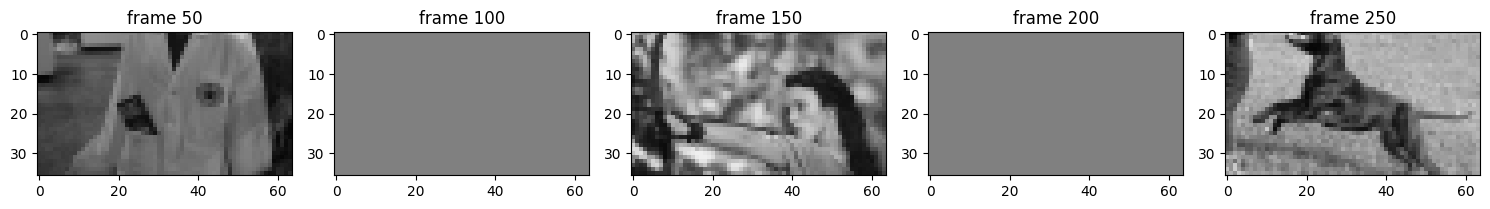

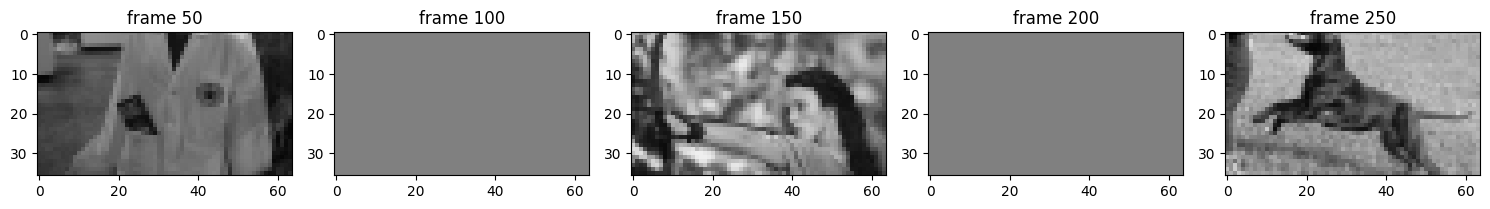

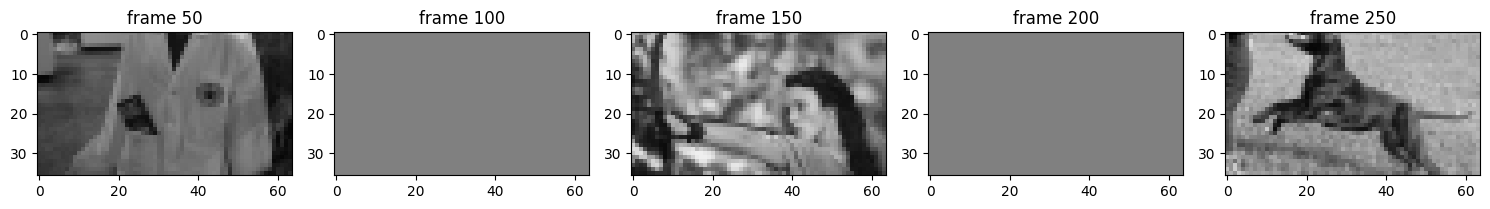

In [48]:
video_1 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='682', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_2 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='670', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_3 = ds.load_video_by_trial(recording='dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='148', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)

frames_plot = np.arange(50, 300, 50).tolist()
fig, ax = video_1.plot_frames(frames_plot)
fig, ax = video_2.plot_frames(frames_plot)
fig, ax = video_3.plot_frames(frames_plot)


In [49]:
ID = "v139482"
df_filtered = ds.filter_trials(video_ID=ID)
df_filtered

,recording,label,video_ID,trial,trial_type,valid_frames,valid_trial,valid_frames_video,valid_frames_response,valid_response
2211,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,716,live_test_bonus,310,True,310,310,True
2287,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,671,live_test_bonus,310,True,310,310,True
2311,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,688,live_test_bonus,310,True,310,310,True
2328,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,673,live_test_bonus,310,True,310,310,True
2462,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,698,live_test_bonus,310,True,310,310,True
2627,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,678,live_test_bonus,310,True,310,310,True
2650,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,677,live_test_bonus,310,True,310,310,True
2677,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,703,live_test_bonus,310,True,310,310,True
2753,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,718,live_test_bonus,310,True,310,310,True
2816,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v139482,687,live_test_bonus,311,True,311,311,True


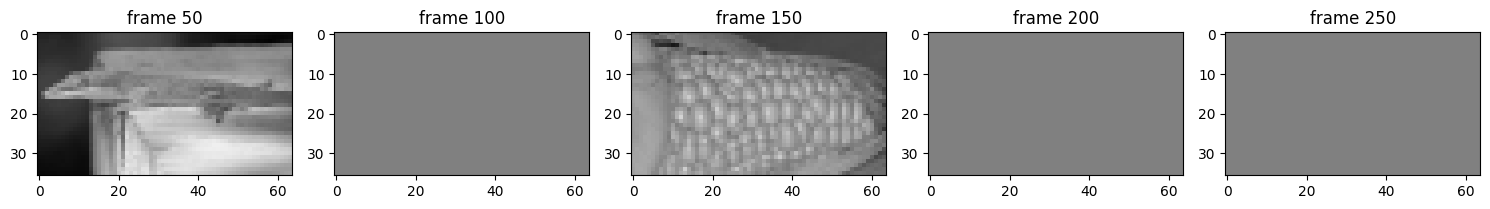

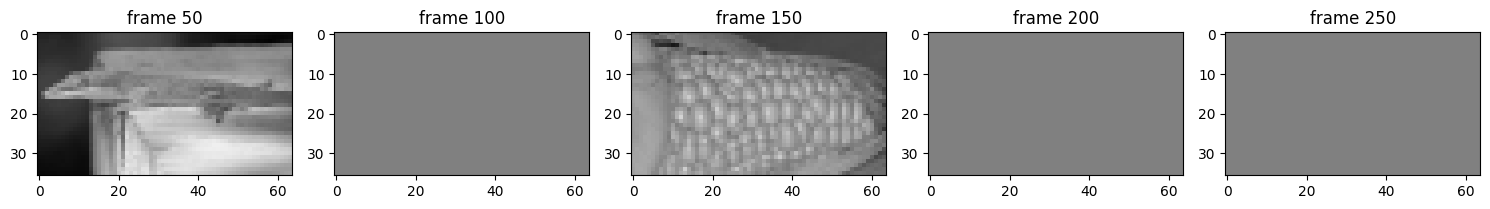

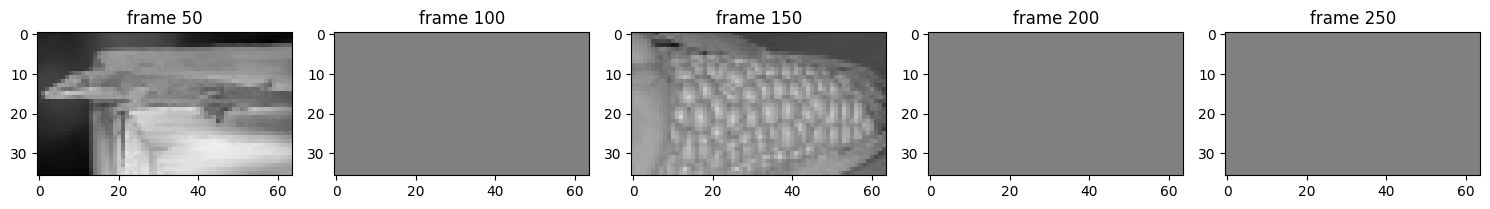

In [50]:
video_1 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='716', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_2 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='687', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_3 = ds.load_video_by_trial(recording='dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='256', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)

frames_plot = np.arange(50, 300, 50).tolist()
fig, ax = video_1.plot_frames(frames_plot)
fig, ax = video_2.plot_frames(frames_plot)
fig, ax = video_3.plot_frames(frames_plot)

In [52]:
ID = "v582341"
df_filtered = ds.filter_trials(video_ID=ID)
df_filtered

,recording,label,video_ID,trial,trial_type,valid_frames,valid_trial,valid_frames_video,valid_frames_response,valid_response
2160,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,685,live_test_bonus,306,True,306,306,True
2249,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,693,live_test_bonus,306,True,306,306,True
2391,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,705,live_test_bonus,306,True,306,306,True
2519,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,702,live_test_bonus,305,True,305,305,True
2537,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,681,live_test_bonus,305,True,305,305,True
2659,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,689,live_test_bonus,305,True,305,305,True
2793,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,719,live_test_bonus,305,True,305,305,True
2852,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v582341,717,live_test_bonus,305,True,305,305,True
5765,dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b...,NaturalImages,v582341,314,final_test_bonus,306,True,306,326,False
5820,dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b...,NaturalImages,v582341,693,final_test_bonus,305,True,305,326,False


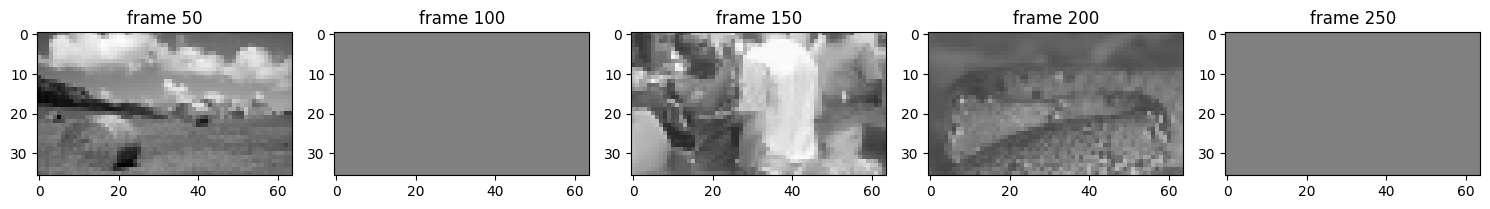

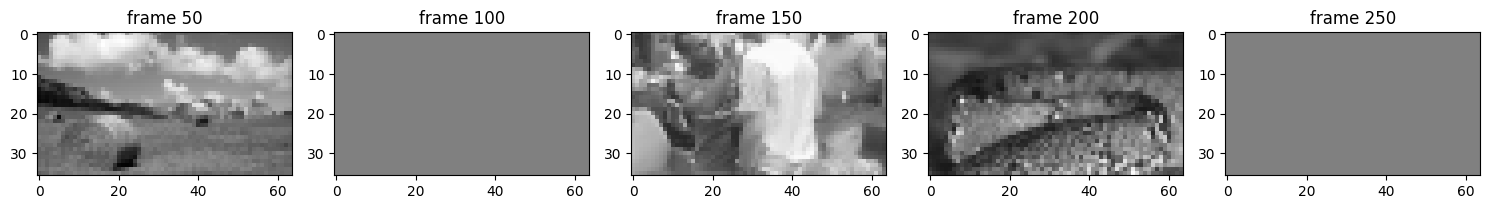

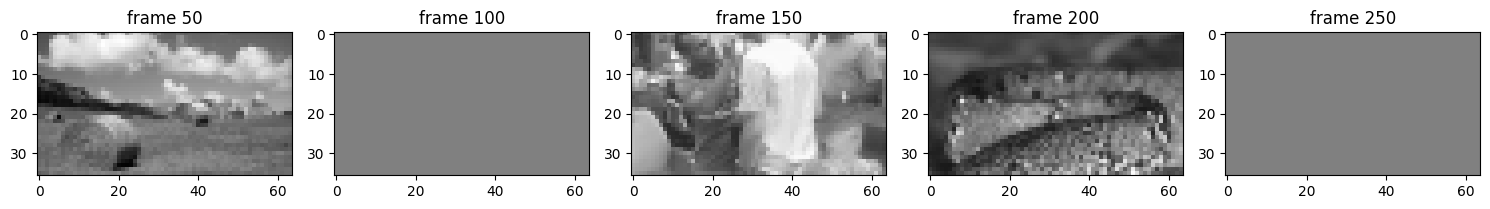

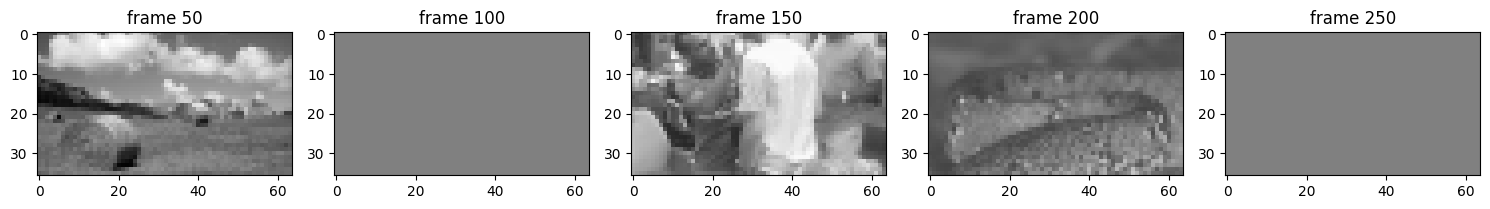

In [53]:
video_1 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='685', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_2 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='681', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_3 = ds.load_video_by_trial(recording='dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='693', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_4 = ds.load_video_by_trial(recording='dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='314', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)

frames_plot = np.arange(50, 300, 50).tolist()
fig, ax = video_1.plot_frames(frames_plot)
fig, ax = video_2.plot_frames(frames_plot)
fig, ax = video_3.plot_frames(frames_plot)
fig, ax = video_4.plot_frames(frames_plot)

In [54]:
ID = "v969497"
df_filtered = ds.filter_trials(video_ID=ID)
df_filtered

,recording,label,video_ID,trial,trial_type,valid_frames,valid_trial,valid_frames_video,valid_frames_response,valid_response
2176,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,665,live_test_bonus,313,True,313,313,True
2274,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,707,live_test_bonus,312,True,312,312,True
2361,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,684,live_test_bonus,313,True,313,313,True
2365,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,683,live_test_bonus,313,True,313,313,True
2529,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,660,live_test_bonus,313,True,313,313,True
2556,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,701,live_test_bonus,313,True,313,313,True
2727,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,715,live_test_bonus,313,True,313,313,True
2752,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,697,live_test_bonus,313,True,313,313,True
2795,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,695,live_test_bonus,312,True,312,312,True
2823,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v969497,661,live_test_bonus,313,True,313,313,True


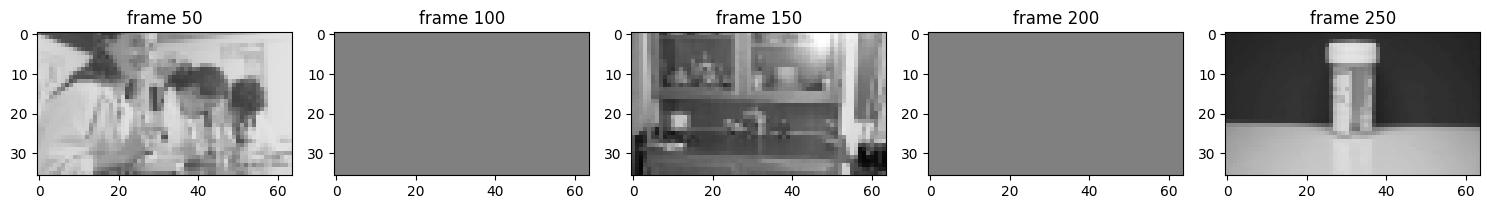

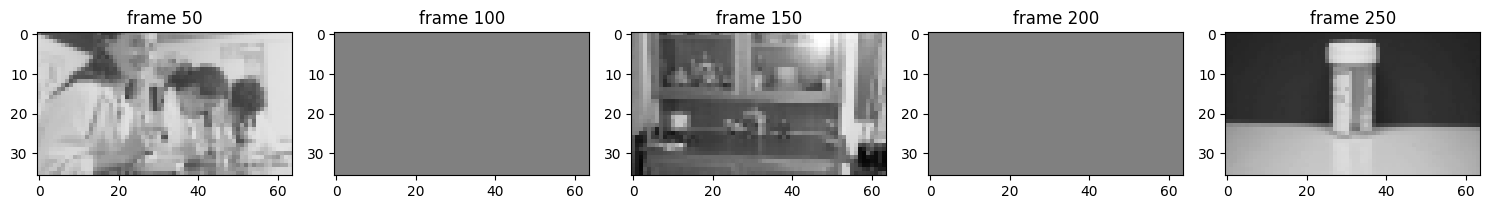

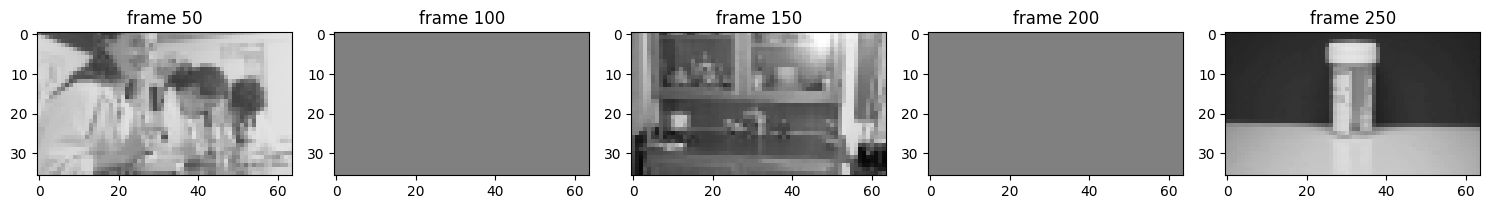

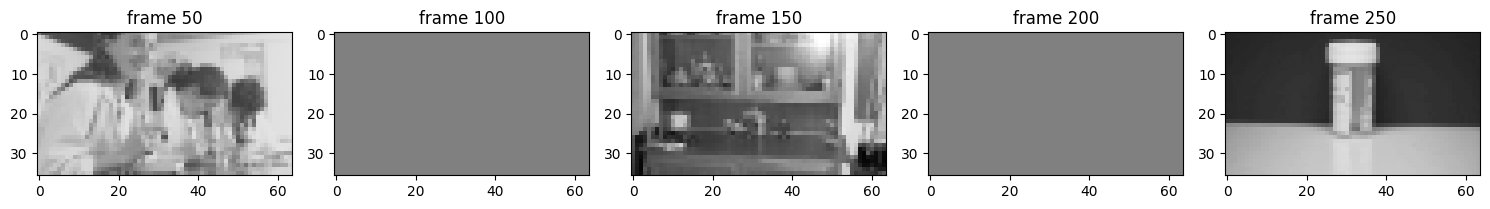

In [55]:
video_1 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='665', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_2 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='707', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_3 = ds.load_video_by_trial(recording='dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='209', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_4 = ds.load_video_by_trial(recording='dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='600', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)

frames_plot = np.arange(50, 300, 50).tolist()
fig, ax = video_1.plot_frames(frames_plot)
fig, ax = video_2.plot_frames(frames_plot)
fig, ax = video_3.plot_frames(frames_plot)
fig, ax = video_4.plot_frames(frames_plot)